In [1]:
import nibabel as nib
from pathlib import Path
from tqdm import tqdm
from matplotlib import pyplot as plt
from parse import parse
import numpy as np
import os 

RAW = Path("/depict/data/hedit/raw/")
DERIVATIVES = Path("/depict/data/hedit/derivatives/pipeline-bodydyn/")

In [2]:
def extract_axial_distribution(p):
    sub = parse(str(RAW)+"/{}/{}",str(p))[0]
    img = nib.load(p)
    y = np.zeros((img.shape[-1],img.shape[2]))
    outfile = f"/homes/hinge/Projects/hedypet-streamlit/axial_distribution_fdg/{sub}.npy"
    if os.path.exists(outfile):
        return
    
    for i in tqdm(range(img.shape[-1])):
        y[i,:] = img.dataobj[...,i].sum(axis=(0,1))
    
    np.save(outfile,y)

for sub in list(RAW.glob("**/*dyn*.nii.gz")):
    extract_axial_distribution(sub)

100%|██████████| 69/69 [01:03<00:00,  1.09it/s]


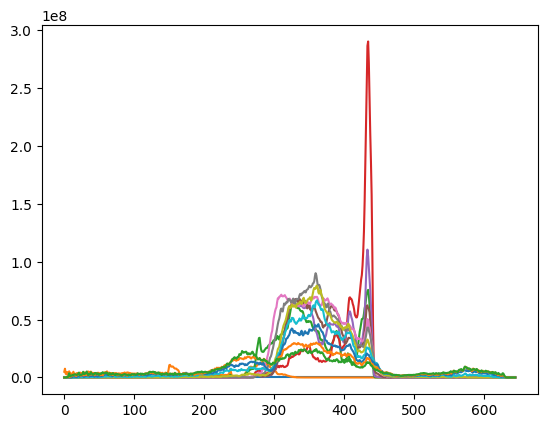

In [16]:
for i in range(13):
    plt.plot(ys[i])